Librerias necesarias para trabajar con ML en python<br>
*Pandas es para el manejo de la información de archivos csv.<br>
*Matplotlib y Seaborn es para las gráficas generadas y que son gracias a la información proporcionada.<br>
*Sklearn es de las librerias más robustas para trabajar ML en python



In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
import seaborn as sns

Leemos el código con la dirección personal de la computadora

In [126]:
df = pd.read_csv("C:\\Users\\jpma2\\Documents\\INNODROP\\DATASET_MUESTRA.csv")


Muestra información necesaria para trabajar con los datos y saber como trabajar con ellos, esto solo es un ejercicio de exploración.

In [127]:
print (df.head())



  Soil_Type  Sunlight_Hours Water_Frequency Fertilizer_Type  Temperature  \
0      loam        5.192294       bi-weekly        chemical    31.719602   
1     sandy        4.033133          weekly         organic    28.919484   
2      loam        8.892769       bi-weekly            none    23.179059   
3      loam        8.241144       bi-weekly            none    18.465886   
4     sandy        8.374043       bi-weekly         organic    18.128741   

    Humidity  Growth_Milestone  
0  61.591861                 0  
1  52.422276                 1  
2  44.660539                 0  
3  46.433227                 0  
4  63.625923                 0  


In [128]:
print (df.describe())

       Sunlight_Hours  Temperature    Humidity  Growth_Milestone
count      193.000000   193.000000  193.000000        193.000000
mean         6.826484    25.076087   58.098927          0.497409
std          1.599509     5.354170   12.631799          0.501294
min          4.033133    15.200000   30.567682          0.000000
25%          5.477000    20.637095   49.300000          0.000000
50%          6.833290    25.912336   59.182806          0.000000
75%          8.241144    29.757938   69.100000          1.000000
max          9.913903    34.810103   79.648240          1.000000


Recorremos el dataset para que nos muestre las categorías que no son datos númericos ya que las computadoras solo pueden hacer calculos utilizando números. 

In [129]:
columnas_texto = df.select_dtypes(include=['object']).columns
for col in columnas_texto:
    print(f"Columna '{col}' -> Categorías únicas: {df[col].unique()}")


Columna 'Soil_Type' -> Categorías únicas: <StringArray>
['loam', 'sandy', 'clay']
Length: 3, dtype: str
Columna 'Water_Frequency' -> Categorías únicas: <StringArray>
['bi-weekly', 'weekly', 'daily']
Length: 3, dtype: str
Columna 'Fertilizer_Type' -> Categorías únicas: <StringArray>
['chemical', 'organic', 'none']
Length: 3, dtype: str


C:\Users\jpma2\AppData\Local\Temp\ipykernel_28108\231868888.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  columnas_texto = df.select_dtypes(include=['object']).columns


Con el LabelEnconcer de la libreria Sklearn le damos el nombre de nuestras columnas que nos aparecieron anteriormente y las transformamos en datos numericos. 

In [130]:
le_soil = LabelEncoder()
le_water = LabelEncoder()
le_fert = LabelEncoder()

df['Soil_Type_Enc'] = le_soil.fit_transform(df['Soil_Type'])
df['Water_Frequency_Enc'] = le_water.fit_transform(df['Water_Frequency'])
df['Fertilizer_Type_Enc'] = le_fert.fit_transform(df['Fertilizer_Type'])

Impresión de el dataset para mostrar que insertamos nuevas columnas que son númericas en lugar de cadenas de string, pero dichas columnas son equivalentes. 

In [131]:
print(df.head())

  Soil_Type  Sunlight_Hours Water_Frequency Fertilizer_Type  Temperature  \
0      loam        5.192294       bi-weekly        chemical    31.719602   
1     sandy        4.033133          weekly         organic    28.919484   
2      loam        8.892769       bi-weekly            none    23.179059   
3      loam        8.241144       bi-weekly            none    18.465886   
4     sandy        8.374043       bi-weekly         organic    18.128741   

    Humidity  Growth_Milestone  Soil_Type_Enc  Water_Frequency_Enc  \
0  61.591861                 0              1                    0   
1  52.422276                 1              2                    2   
2  44.660539                 0              1                    0   
3  46.433227                 0              1                    0   
4  63.625923                 0              2                    0   

   Fertilizer_Type_Enc  
0                    0  
1                    2  
2                    1  
3                    1

Seleccionamos las celdas utiles del dataset, en este ejemplo consideramos todas las variables como predictoras y la variable a predecir es 'Growth_Milestone'

In [132]:
X = df[['Soil_Type_Enc', 'Sunlight_Hours', 'Water_Frequency_Enc', 'Fertilizer_Type_Enc', 'Temperature', 'Humidity']]
y = df['Growth_Milestone']

El dataset se divide en entrenamiento y test de forma aleatoria en 80% entrenamiento y 20% validación o test.

In [133]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

Asignamos a una nueva variable la aplicación de nuestro Bosque Aleatorio, ponemos el número de arboles que necesitaremos y seleccionamos una semilla para que no cambie con cada ejecución del código, podemos aumentar el 'n_estimators' que hace referencia al número de arboles, el número depende del poder computacional con el que se cuenta. Y la semilla fue seleccionada al azar.<br>
El 'modelo.fit(X_train, y_train)' es de los principales comandos de la libreria, significa entrenar y le damos la variable de entrada y de salida que definimos anteriormente.  

In [206]:
modelo = RandomForestClassifier(n_estimators=101, random_state =42)
modelo.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",101
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstr

Hacemos la comprobación del modelo y nos imprime la precisión. 

In [208]:
precision = modelo.score(X_test, y_test)
print(f"¡Modelo ha sido entrenado y tiene una precisión: {precision * 100:.2f}%")

¡Modelo ha sido entrenado y tiene una precisión: 61.54%


Imprimir gráficos y son configuraciones del mismo

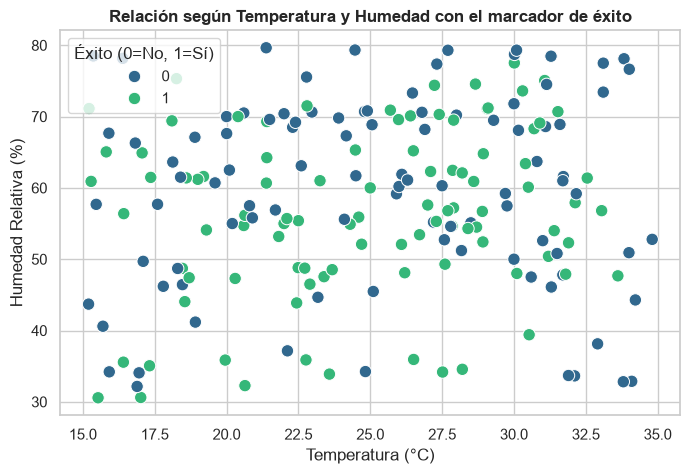

In [216]:
plt.figure(figsize=(8, 5))
sns.scatterplot(data=df, x='Temperature', y='Humidity', hue='Growth_Milestone', palette='viridis', s=80)
plt.title('Relación según Temperatura y Humedad con el marcador de éxito', fontsize=12, fontweight='bold')
plt.xlabel('Temperatura (°C)')
plt.ylabel('Humedad Relativa (%)')
plt.legend(title='Éxito (0=No, 1=Sí)')
plt.show()


Con la gráfica se llega a la conclusión en que no existe una relación directa de la humedad y de temperatura y esto nos permite entender que es necesario algún tipo de control biológico y tecnológico ya que por si solas las condiciones de humedad que se dan por riego son un volado al aire. 

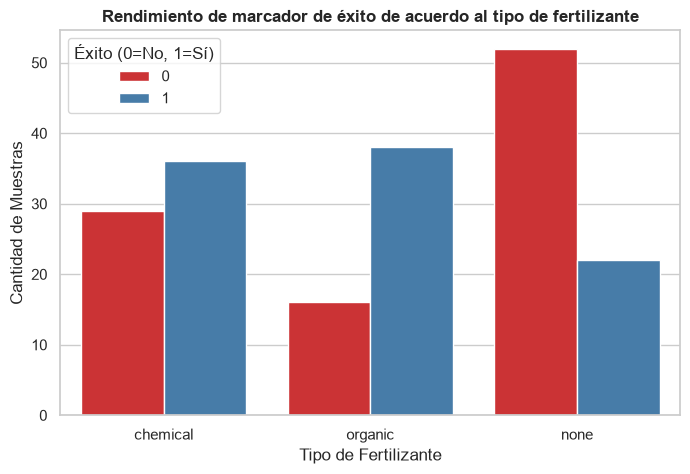

In [219]:
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x='Fertilizer_Type', hue='Growth_Milestone', palette='Set1')
plt.title('Rendimiento de marcador de éxito de acuerdo al tipo de fertilizante', fontsize=12, fontweight='bold')
plt.xlabel('Tipo de Fertilizante')
plt.ylabel('Cantidad de Muestras')
plt.legend(title='Éxito (0=No, 1=Sí)')
plt.show()

En la gráfica se observa cómo los fertilizantes organicos presentan mayor porcentaje de éxito por lo que uso de micorrizas es una opción viable. 